In [1]:
"""
Retrieves a day's worth of data for every symbol that day
Calculates out periods of high volatility
"""

import duckdb
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime
import os
import plotly.express as px
import gc


USER_DATE = "20260706" #YYYYMMDD INPUT HERE
USER_SYMBOL = "BTC-USD"

BASE = Path("/app")
if BASE.exists():
    print(f"Contents of /app: {os.listdir('/app')}")
else:
    print("/app does not exist. Check your docker-compose.yml configuration.")


try:
    datetime.strptime(USER_DATE, "%Y%m%d")
except Exception:
    print(f"INVALID DATE {USER_DATE}")

DATA_PATH = BASE / "data" / "**" / "*.snappy.parquet"
if Path("/app/data").exists():
    print(f"Contents of /app/data: {os.listdir('/app')}")
else:
    print("/app/data does not exist. Check your docker-compose.yml configuration.")

Contents of /app: ['prepush_check', '.git', 'pyproject.toml', '.venv', 'README.md', '.github', 'backend', '.dockerignore', 'docker-compose.yml', 'requirements.txt', 'LICENSE', 'venv', '.pytest_cache', 'notebooks', '.gitignore', 'pre-push', 'clean-logs', 'data', '.mypy_cache', '.ruff_cache', 'project-up', 'Dockerfile']
Contents of /app/data: ['prepush_check', '.git', 'pyproject.toml', '.venv', 'README.md', '.github', 'backend', '.dockerignore', 'docker-compose.yml', 'requirements.txt', 'LICENSE', 'venv', '.pytest_cache', 'notebooks', '.gitignore', 'pre-push', 'clean-logs', 'data', '.mypy_cache', '.ruff_cache', 'project-up', 'Dockerfile']


In [2]:
con = duckdb.connect()
con.execute("INSTALL delta; LOAD delta;")
pd.options.display.max_rows = 25

In [3]:

df = con.execute(f"""
            SELECT 
                *
            FROM read_parquet('{DATA_PATH}', hive_partitioning=true)
            WHERE year = ? AND month = ? AND day = ? and product_id=?
        """, ['2026', "07", "06", USER_SYMBOL]).fetchdf().dropna()
df["type"] = df["type"].astype("category")
df.product_id = df.product_id.astype("category")
df.side = df.side.astype("category")
df.index = df.time

In [4]:
df.columns
df = df.sort_values(by=["sequence"])

In [5]:
df.describe()

,sequence,price,open_24h,volume_24h,low_24h,high_24h,volume_30d,best_bid,best_bid_size,best_ask,best_ask_size,last_size,trade_id,Recieved,year
count,2.198050e+05,219805.000000,219805.000000,219805.000000,219805.0,219805.00,219805.000000,219805.000000,2.198050e+05,219805.000000,2.198050e+05,2.198050e+05,2.198050e+05,219805,219805.0
mean,1.321397e+11,63540.519580,62641.656951,8779.803303,61250.0,63940.79,237368.326824,63539.654332,1.140117e-01,63541.186826,1.727732e-01,1.742432e-02,1.051236e+09,2026-07-06 17:29:48.634248,2026.0
min,1.321292e+11,62218.900000,62569.990000,7191.150916,61250.0,63940.79,235383.061880,62218.900000,1.000000e-08,62218.910000,1.000000e-08,1.000000e-08,1.051126e+09,2026-07-06 15:25:45.861965,2026.0
25%,1.321349e+11,63524.420000,62569.990000,8070.590782,61250.0,63940.79,236499.555562,63524.000000,8.367230e-03,63524.870000,1.591697e-02,7.500000e-07,1.051181e+09,2026-07-06 16:14:46.277524,2026.0
50%,1.321396e+11,63659.020000,62673.930000,8798.086546,61250.0,63940.79,237388.735296,63658.240000,3.760508e-02,63660.000000,6.423886e-02,5.747100e-04,1.051236e+09,2026-07-06 17:07:08.769070,2026.0
75%,1.321446e+11,63745.110000,62711.000000,9520.824825,61250.0,63940.79,238323.885994,63745.090000,1.115942e-01,63745.960000,1.624909e-01,1.429731e-02,1.051291e+09,2026-07-06 18:36:53.122692,2026.0
max,1.321505e+11,63938.390000,63034.980000,10083.924224,61250.0,63940.79,239268.010608,63938.390000,1.446538e+01,63938.400000,3.000000e+01,2.991884e+01,1.051353e+09,2026-07-06 21:00:42.240706,2026.0
std,5.848083e+06,368.794457,73.841559,800.676793,0.0,0.00,1070.137555,368.970036,2.718976e-01,368.625473,5.327751e-01,1.107102e-01,6.364077e+04,NaN,0.0


In [6]:
df["ordering"] = df.sequence - df.sequence.shift(1)
df["ordering"] = np.where(df.ordering == 0, 0.001, df.ordering) #quickly make sure values aren't 0, log is undefined at 0
invalid_entries = df[df["ordering"].notna()]
mean = invalid_entries.ordering.mean()
print(f" Mean {mean}")

 Mean 97.11364215391895


In [7]:
df["log_ordering"] = np.log(df.ordering)
gdf = df[["log_ordering","ordering"]].set_index(df.index).copy(True)
#resample to try to reduce jitter
gdf = gdf.resample("1Min").mean()
df = None
gc.collect() #avoid storing massive dataframe in memory

4

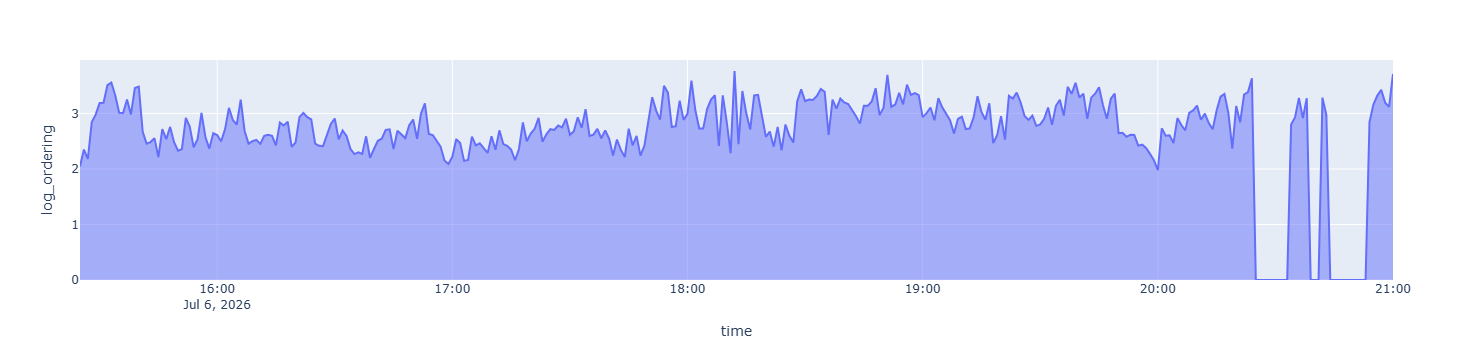

In [8]:
#log scale to smooth the plot out
fig = px.area(gdf, x=gdf.index, y="log_ordering")
fig.show()

In [9]:
gdf = None
gc.collect()


16